# 06 · V10 — Regime-adaptive Kalman dynamic-factor (Kalman *instead of* PCA)

Deepens **V0** and **V5**: replace V0's `StandardScaler + PCA → PC1 → re-3y-z` with a **Kalman
dynamic factor** over the *same* 7-KPI panel. The filtered latent factor is a "far more informed,
dynamic average" of the KPIs (a dynamic PC1 with proper covariance); the standardized **innovation**
(multivariate NIS) is the **deviation from that informed average**. A **break-of-structure filter**
(CUSUM of recursive residuals + V8 BOCPD) monitors process stability; on a break the model **retrains**
(re-standardizes to the new regime) and **resamples** the new-regime distribution to build **robust
quantile bands with bootstrap CIs** — so "crowded/extreme" is calibrated to the regime's actual
(skewed, fat-tailed) distribution, not a fixed ±1.5σ.

Given the prior result (richer deviations don't predict forward yields here), V10 is judged on
**state-estimation quality** — band **calibration/coverage**, break detection, and **adaptivity vs V0**
— with the strict forward-return gate reported only as an honest secondary.

*Refs: dynamic factor models (Stock–Watson); Kalman NIS consistency; Brown–Durbin–Evans CUSUM;
Peaks-Over-Threshold / GPD; bootstrap CIs.*

In [1]:
import sys, os
# Make the notebook self-sufficient: walk up from cwd to the repo root (dir containing `positioning`).
_root = os.getcwd()
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, "positioning")):
    _root = os.path.dirname(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)

import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    def display(x): print(x)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
ORANGE="#FF8200"; GREY="#3C3C3C"; BLUE="#1F4E79"; RED="#C00000"; GREEN="#2E7D32"; PURPLE="#7030A0"; TEAL="#0F9D9D"

from positioning.versions import base, compare, richness, dsp, transforms
from positioning.versions import params as P
from positioning.versions.base import responsiveness

def show(df, n=None):
    """Render a DataFrame/dict, truncated."""
    try:
        display(df if n is None else df.head(n))
    except Exception:
        print(df)

def zline(ax, bounded=False):
    """Draw crowd bands for a composite axis."""
    if bounded:
        ax.axhline(80, color=RED, ls="--", lw=0.7); ax.axhline(20, color=GREEN, ls="--", lw=0.7)
    else:
        for k in (1.5, -1.5): ax.axhline(k, color=GREY, ls="--", lw=0.6)
        ax.axhline(0, color=GREY, lw=0.4)

def crossings(z, level=0.0):
    """Count sign changes of (z-level): a proxy for 'deviations per unit time'."""
    s = z.dropna().astype(float) - level
    return int((np.sign(s).diff().abs() > 0).sum())

print("loaded versions package — building shared inputs (cache-first)…")
inp = base.load_inputs()
y10 = inp.y10_w
print(f"inputs: {len(inp.report_dates)} weekly dates {inp.report_dates.min().date()}..{inp.report_dates.max().date()}")

loaded versions package — building shared inputs (cache-first)…


inputs: 422 weekly dates 2018-06-19..2026-07-14


In [2]:
from positioning.versions import regime
from positioning.core import score as score_mod
inp, results = compare.build_all()
r10 = results["v10"]; meta = r10.meta
dev = r10.composite.dropna()      # headline: deviation from the informed average (NIS)
fac = r10.curve.dropna()          # filtered latent factor = dynamic PC1 (informed average)
v0  = results["v0"].composite.dropna()
print("DFM converged:", meta.get("dfm_converged"), "| fit:", meta.get("fit_mode_used"), meta.get("fit_scope"))
print("factor vs V0 corr:", meta.get("corr_with_v0"), "| deviation_std:", round(meta.get("deviation_std", float("nan")),2))
print("first_break:", meta.get("first_break"), "| retrained_at:", meta.get("retrained_at"))

/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


DFM converged: True | fit: auto full
factor vs V0 corr: 0.33706350118386846 | deviation_std: 1.14
first_break: 2020-03-24 | retrained_at: 2020-03-24


## Deepen V0 — the 7-KPI panel the PCA (and now the Kalman) consumes

In [3]:
fp = score_mod.run_score(inp.fut_raw, inp.cash_raw, inp.yields_raw).feature_panel
print("feature_panel:", fp.shape, "->", list(fp.columns))
show(fp.dropna().tail(4).round(2))

feature_panel: (422, 7) -> ['lev_money_level_z', 'lev_money_flow_z', 'asset_mgr_level_z', 'asset_mgr_flow_z', 'curve_z', 'conc_z', 'cash_z']


,lev_money_level_z,lev_money_flow_z,asset_mgr_level_z,asset_mgr_flow_z,curve_z,conc_z,cash_z
date,,,,,,,
2026-06-23,-0.10,0.46,1.34,0.45,1.36,1.91,1.79
2026-06-30,-0.13,-0.37,1.23,-0.74,1.35,1.71,1.85
2026-07-07,-0.25,-1.06,1.23,0.10,1.39,1.77,1.76
2026-07-14,-0.25,-0.15,1.21,-0.13,1.46,1.79,1.60


## 1 · Kalman factor (dynamic PC1) vs V0 PCA composite — is it faster / less lagged?

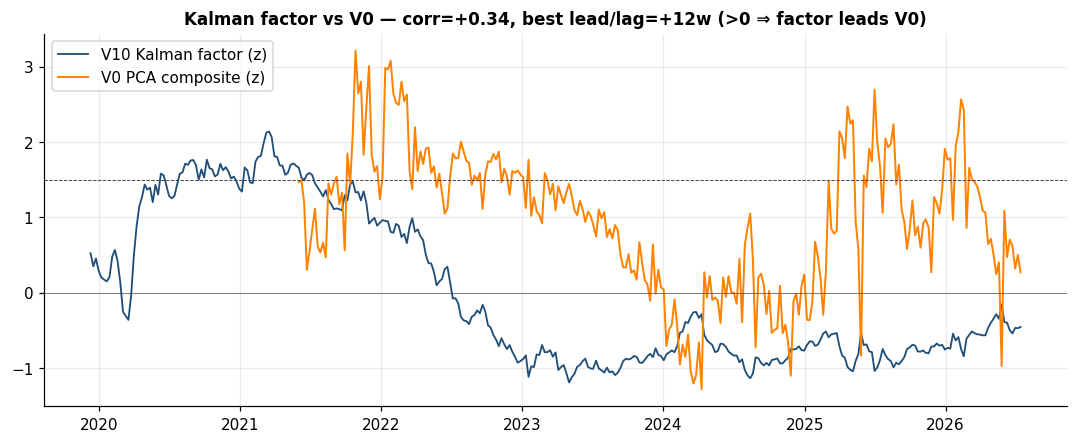

In [4]:
al = pd.concat([fac.rename("f"), v0.rename("v0")], axis=1).dropna()
lags = range(-12, 13)
cc = [al["f"].shift(k).corr(al["v0"]) for k in lags]
best = list(lags)[int(np.nanargmax(np.abs(cc)))]
fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(fac.index, (fac - fac.mean())/ (fac.std() or 1), color=BLUE, lw=1.2, label="V10 Kalman factor (z)")
ax.plot(v0.index, richness.to_z(v0, False), color=ORANGE, lw=1.3, label="V0 PCA composite (z)")
zline(ax); ax.legend(loc="upper left")
ax.set_title(f"Kalman factor vs V0 — corr={al['f'].corr(al['v0']):+.2f}, best lead/lag={best:+d}w (>0 ⇒ factor leads V0)")
display(fig); plt.close(fig)

## 2 · Deviation from the informed average (multivariate NIS) — deepening V5

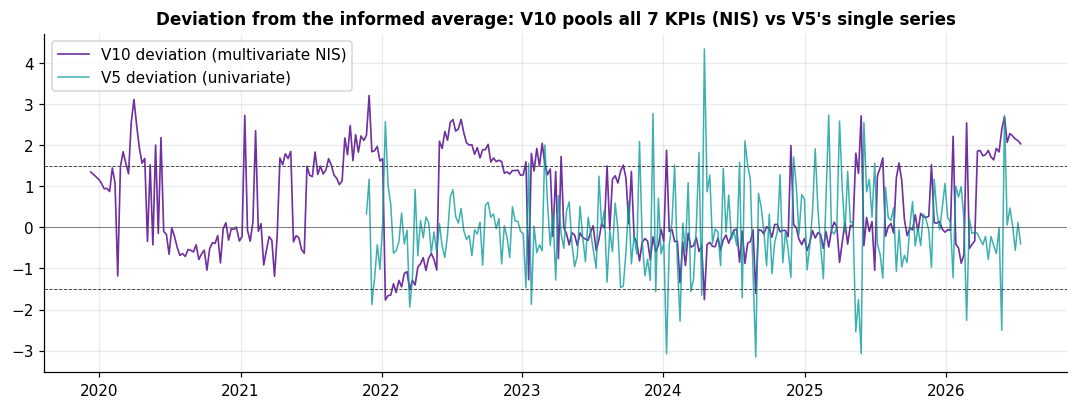

In [5]:
r5 = results["v5"].composite.dropna()      # V5 = univariate Kalman deviation
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dev.index, dev.values, color=PURPLE, lw=1.1, label="V10 deviation (multivariate NIS)")
ax.plot(r5.index, richness.to_z(r5, False), color=TEAL, lw=1.0, alpha=0.8, label="V5 deviation (univariate)")
zline(ax); ax.legend(loc="upper left")
ax.set_title("Deviation from the informed average: V10 pools all 7 KPIs (NIS) vs V5's single series")
display(fig); plt.close(fig)

## 3 · Break-of-structure filter — process stability (rare by design; sanity: 2020/2022)

top break-prob dates: ['2022-01-18', '2019-12-31', '2019-12-24', '2019-12-17', '2019-12-10']


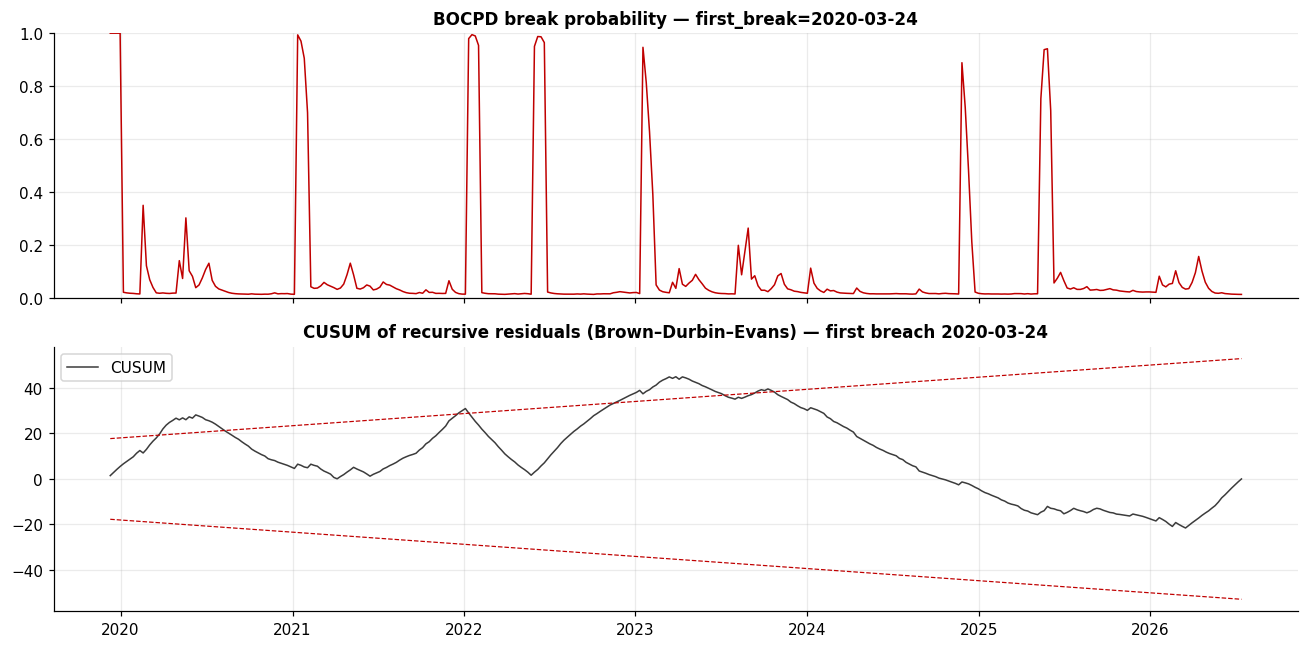

In [6]:
bp = meta.get("break_prob"); cusum = meta.get("cusum", {}) or {}
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
if hasattr(bp, "dropna"):
    b = bp.dropna(); axes[0].plot(b.index, b.values, color=RED, lw=1.0); axes[0].set_ylim(0, 1)
    top = [str(d.date()) for d in b.sort_values().index[-5:]]
    print("top break-prob dates:", top)
axes[0].set_title(f"BOCPD break probability — first_break={meta.get('first_break')}")
cu = cusum.get("cusum"); hi = cusum.get("boundary_hi"); lo = cusum.get("boundary_lo")
if hasattr(cu, "dropna"):
    axes[1].plot(cu.index, cu.values, color=GREY, lw=1.0, label="CUSUM")
    axes[1].plot(hi.index, hi.values, color=RED, ls="--", lw=0.8)
    axes[1].plot(lo.index, lo.values, color=RED, ls="--", lw=0.8)
    axes[1].legend(loc="upper left")
axes[1].set_title(f"CUSUM of recursive residuals (Brown–Durbin–Evans) — first breach {cusum.get('first_breach')}")
fig.tight_layout(); display(fig); plt.close(fig)

## 4 · Regime-resampled ROBUST bands (headline) + calibration/coverage

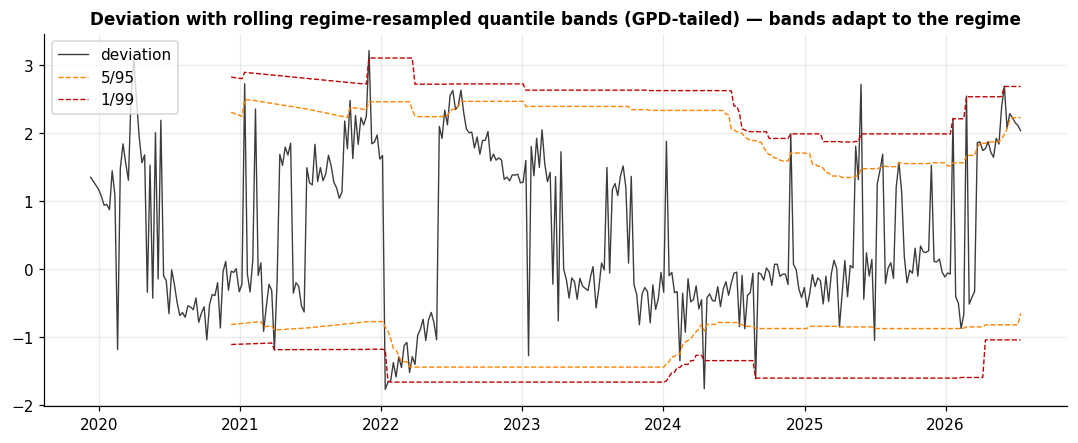

,quantile,point,ci_lo,ci_hi
0,0.01,-1.041,-1.610,-0.664
1,0.05,-0.651,-0.878,-0.443
2,0.95,2.226,1.990,2.519
3,0.99,2.684,2.280,2.717


,quantile,breach_rate,nominal,well_calibrated
0,0.01,0.017,0.01,True
1,0.05,0.061,0.05,True
2,0.95,0.082,0.05,True
3,0.99,0.020,0.01,False


Calibration: breach_rate should sit near nominal (≈5% beyond the 95% band, ≈1% beyond the 99%).


In [7]:
rw = (meta.get("params", {}) or {}).get("regime_window", 104)
rb = meta.get("rolling_bands")
if not isinstance(rb, pd.DataFrame):
    rb = regime.rolling_resampled_bands(dev, window=rw)
fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(dev.index, dev.values, color=GREY, lw=0.9, label="deviation")
for col, color, lab in [("q0.95", ORANGE, "5/95"), ("q0.05", ORANGE, None),
                         ("q0.99", RED, "1/99"), ("q0.01", RED, None)]:
    if col in rb.columns:
        ax.plot(rb.index, rb[col].values, color=color, lw=0.9, ls="--", label=lab)
ax.legend(loc="upper left")
ax.set_title("Deviation with rolling regime-resampled quantile bands (GPD-tailed) — bands adapt to the regime")
display(fig); plt.close(fig)

bands = meta.get("resampled_bands", {}) or {}
show(pd.DataFrame([{"quantile": q, "point": v.get("point"), "ci_lo": v.get("lo"), "ci_hi": v.get("hi")}
                   for q, v in bands.items() if isinstance(v, dict)]).round(3))
cov = meta.get("coverage", {}) or {}
show(pd.DataFrame([{"quantile": q, "breach_rate": v.get("breach_rate"), "nominal": v.get("nominal"),
                    "well_calibrated": v.get("well_calibrated")}
                   for q, v in cov.items() if isinstance(v, dict)]).round(3))
print("Calibration: breach_rate should sit near nominal (≈5% beyond the 95% band, ≈1% beyond the 99%).")

## 5 · Adaptivity vs V0, and the honest forward-return gate

In [8]:
resp10 = responsiveness(fac, False); resp0 = responsiveness(v0, False)
print("factor first crowd-flag:", resp10.get("first_flag"), "| V0 first flag:", resp0.get("first_flag"),
      "| factor lead (wks):", resp10.get("weeks_since_flag"), "vs V0", resp0.get("weeks_since_flag"))
s = richness.score(dev, inp.y10_w, bounded=False, baseline=v0, name="v10")
g = s.get("gate") or {}
print("richness gate (honest secondary): pass=%s incr_ic=%s surrogate_p=%s cpcv_ic=%s t=%s"
      % (g.get("pass"), g.get("incremental_ic"), g.get("surrogate_p"), g.get("cpcv_ic"), g.get("t")))

factor first crowd-flag: None | V0 first flag: 2025-04-01 | factor lead (wks): None vs V0 67


richness gate (honest secondary): pass=False incr_ic=-0.16931805644877848 surrogate_p=0.5 cpcv_ic=0.032546795341904786 t=-0.7340548411118044


## Scorecard — V10 alongside V0 / V5 / V8

In [9]:
sc = richness.scorecard({k: results[k] for k in ["v0", "v5", "v8", "v10"]}, inp.y10_w, baseline_key="v0")
show(sc.round(3))

,cross0_per_yr,cross1_per_yr,cross2_per_yr,turns_per_yr,bienayme_z,half_life_wk,spectral_entropy,ic_8w,ic_t_8w,incr_ic,surrogate_p,cpcv_ic,gate_pass
v0,6.209,7.567,4.269,33.955,-0.339,4.567,0.520,0.163,0.692,NaN,NaN,NaN,False
v5,23.325,23.539,7.276,36.593,1.578,0.663,0.879,-0.038,-0.585,-0.374,0.010,-0.021,False
v8,13.360,13.098,0.000,27.113,-6.721,1.595,0.825,-0.047,-0.471,-0.259,0.445,-0.006,False
v10,10.852,10.551,3.316,35.571,0.939,2.182,0.725,-0.090,-0.734,-0.169,0.500,0.033,False


## Takeaway
V10 answers the brief: a **Kalman dynamic factor replaces PCA** as a *more informed, dynamic average*
of the KPIs; the **NIS innovation** is the deviation from it; a **break filter** flags the rare
structural shifts; and on a break the model **retrains + resamples** the new regime to produce **robust,
regime-calibrated bands with confidence intervals** rather than a static ±1.5σ. Success is read from
**calibration/coverage + adaptivity vs V0**, not forward-return prediction (reported honestly as a
secondary). The resampled bands are the durable, usable output: crowding thresholds that stay
well-calibrated as the positioning regime changes.